<a href="https://colab.research.google.com/github/gracey25/us-foreign-aid-democracy-analysis/blob/main/02_eda_visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Create nested directory structure automatically
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Upload CSV from your computer

# Set global style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

In [3]:
# ==========================================
# 1. LOAD PROCESSED PANEL DATASET
# ==========================================
df = pd.read_csv("../data/processed/merged_vdem_aid_panel (1).csv")

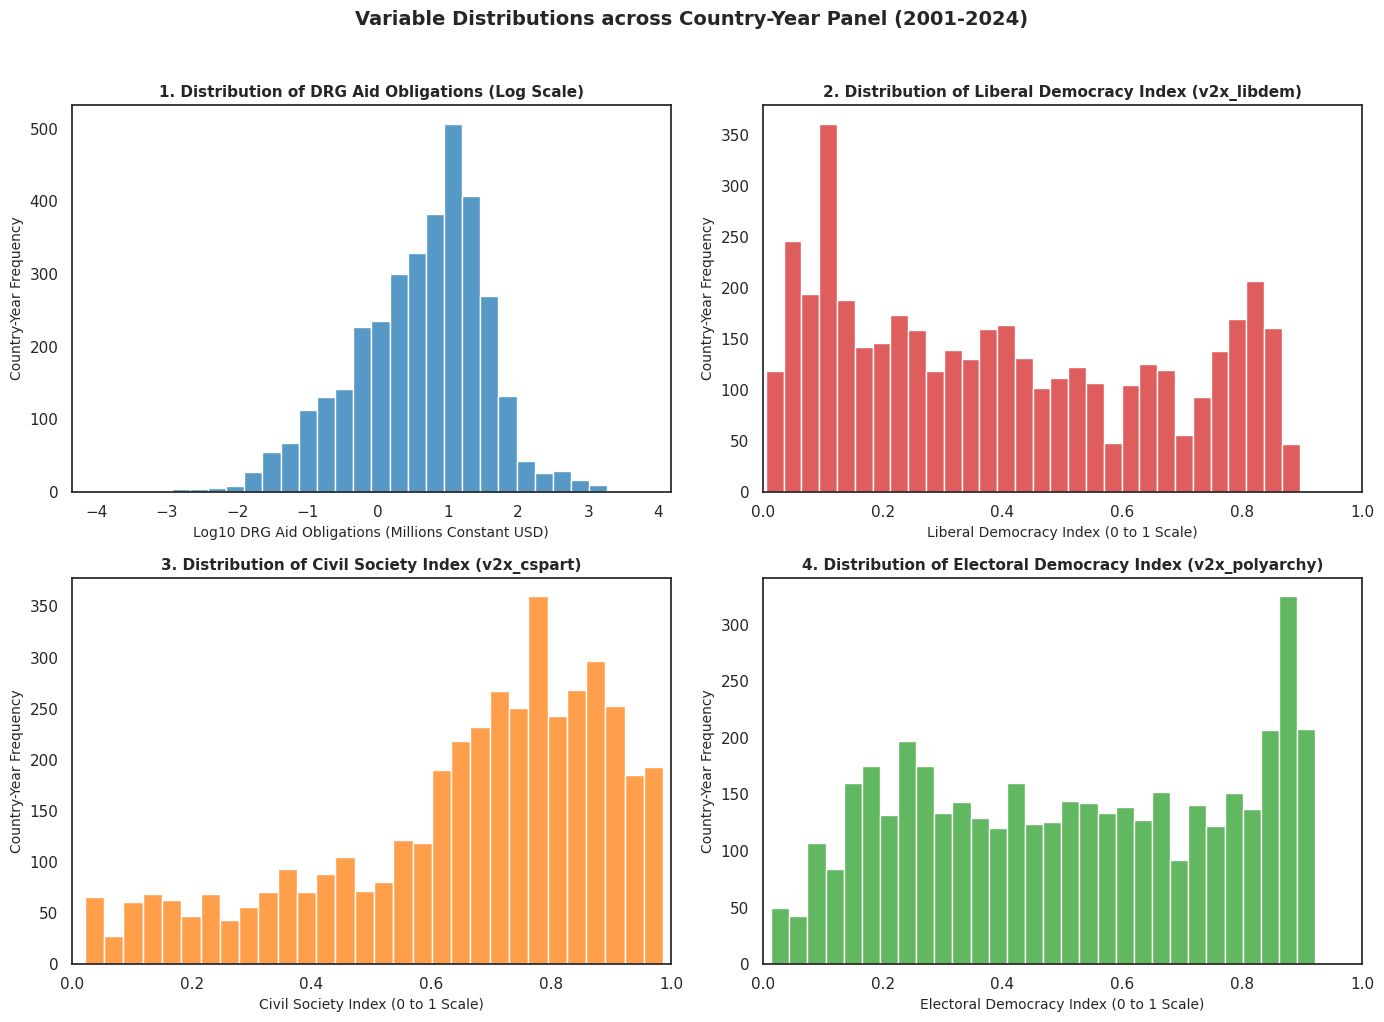

Histogram grid saved successfully to: ../outputs/fig_variable_distributions_2x2.png


In [8]:
# ==========================================
# SINGLE VARIABLE VISUALIZATIONS
# ==========================================

# Create 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Color palette for variables
colors = {
    'aid': '#1f77b4',       # Slate Blue
    'libdem': '#d62728',    # Crimson Red
    'cspart': '#ff7f0e',    # Amber Orange
    'polyarchy': '#2ca02c'  # Emerald Green
}

# ---------------------------------------------------------
# 1. Distribution of DRG Aid Obligations (Log Scale)
# ---------------------------------------------------------
df['aid_millions'] = df['aid_constant_amount'] / 1e6
aid_data = df[df['aid_millions'] > 0]['aid_millions']
log_aid_data = np.log10(aid_data) # used log bc there are some enormous outliers on the upper end

sns.histplot(
    log_aid_data,
    kde=False,
    color=colors['aid'],
    ax=axes[0, 0],
    bins=30
)
axes[0, 0].set_title('1. Distribution of DRG Aid Obligations (Log Scale)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Log10 DRG Aid Obligations (Millions Constant USD)', fontsize=10)
axes[0, 0].set_ylabel('Country-Year Frequency', fontsize=10)

# ---------------------------------------------------------
# 2. Distribution of Liberal Democracy Index (v2x_libdem)
# ---------------------------------------------------------
sns.histplot(
    df['v2x_libdem'].dropna(),
    kde=False,
    color=colors['libdem'],
    ax=axes[0, 1],
    bins=30
)
axes[0, 1].set_title('2. Distribution of Liberal Democracy Index (v2x_libdem)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Liberal Democracy Index (0 to 1 Scale)', fontsize=10)
axes[0, 1].set_ylabel('Country-Year Frequency', fontsize=10)
axes[0, 1].set_xlim(0, 1)

# ---------------------------------------------------------
# 3. Distribution of Civil Society Participation Index (v2x_cspart)
# ---------------------------------------------------------
sns.histplot(
    df['v2x_cspart'].dropna(),
    kde=False,
    color=colors['cspart'],
    ax=axes[1, 0],
    bins=30
)
axes[1, 0].set_title('3. Distribution of Civil Society Index (v2x_cspart)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Civil Society Index (0 to 1 Scale)', fontsize=10)
axes[1, 0].set_ylabel('Country-Year Frequency', fontsize=10)
axes[1, 0].set_xlim(0, 1)

# ---------------------------------------------------------
# 4. Distribution of Electoral Democracy Index (v2x_polyarchy)
# ---------------------------------------------------------
sns.histplot(
    df['v2x_polyarchy'].dropna(),
    kde=False,
    color=colors['polyarchy'],
    ax=axes[1, 1],
    bins=30
)
axes[1, 1].set_title('4. Distribution of Electoral Democracy Index (v2x_polyarchy)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Electoral Democracy Index (0 to 1 Scale)', fontsize=10)
axes[1, 1].set_ylabel('Country-Year Frequency', fontsize=10)
axes[1, 1].set_xlim(0, 1)

plt.suptitle('Variable Distributions across Country-Year Panel (2001-2024)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save FIRST, then display
output_dist_path = "../outputs/fig_variable_distributions_2x2.png"
plt.savefig(output_dist_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Histogram grid saved successfully to: {output_dist_path}")

In [10]:
# ==========================================
# VISUALIZATION OF RAW AID DATA (NOT LOG) WITH OUTLIERS EXCLUDED
# ==========================================

# Select aid data (filtering to positive allocations)
aid_series = df[df['aid_millions'] > 0]['aid_millions']

# Compute quartiles and IQR
q1 = aid_series.quantile(0.25)
q3 = aid_series.quantile(0.75)
iqr = q3 - q1

# Define upper bound (1.5 IQRs above Q3)
upper_bound = q3 + (1.5 * iqr)

# Filter aid data within 1.5 IQRs of the upper bound
filtered_aid = aid_series[aid_series <= upper_bound]

# Report observations removed
removed_count = len(aid_series) - len(filtered_aid)
print(f"Q1 (25th Pct): ${q1:.2f}M")
print(f"Q3 (75th Pct): ${q3:.2f}M")
print(f"IQR: ${iqr:.2f}M")
print(f"Upper Threshold (Q3 + 1.5*IQR): ${upper_bound:.2f}M")
print(f"Excluded {removed_count} outlier observations above ${upper_bound:.2f}M")

# Plot raw histogram without log scale
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    filtered_aid,
    bins=30,
    kde=False,
    color='#1f77b4',
    ax=ax
)

ax.set_title(f'Distribution of DRG Aid Obligations (Excluding Outliers > ${upper_bound:.1f}M)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('DRG Aid Obligations (Millions Constant USD)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Country-Year Frequency', fontsize=11, fontweight='bold', labelpad=10)

plt.tight_layout()

# Save FIRST, then display
output_filtered_path = "../outputs/fig_aid_histogram_no_outliers.png"
plt.savefig(output_filtered_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Filtered histogram saved to: {output_filtered_path}")

3474

In [11]:
# ==========================================
# NUMERIC SUMMARIES
# ==========================================

# List of target variables
target_vars = [
    'aid_millions',
    'v2x_libdem',
    'v2x_cspart',
    'v2x_polyarchy'
]

# Generate descriptive statistics dataframe
summary_stats = df[target_vars].describe().T

# Add missing values count and rename columns for clean presentation
summary_stats = summary_stats.rename(columns={
    'count': 'N',
    'mean': 'Mean',
    'std': 'Std Dev',
    'min': 'Min',
    '25%': '25th Pct',
    '50%': 'Median',
    '75%': '75th Pct',
    'max': 'Max'
})

# Reorder columns logically
cols_order = ['N', 'Mean', 'Std Dev', 'Min', '25th Pct', 'Median', '75th Pct', 'Max']
summary_stats = summary_stats[cols_order]

# Display formatted summary table
print("=== DESCRIPTIVE STATISTICS: NUMERIC VARIABLES ===")
display(summary_stats.round(2))

# Save summary statistics to CSV for Phase 3 reporting
output_csv_path = "../outputs/table1_descriptive_statistics.csv"
summary_stats.to_csv(output_csv_path)

print(f"\n✅ Summary statistics successfully saved to: {output_csv_path}")

=== DESCRIPTIVE STATISTICS: NUMERIC VARIABLES ===


,N,Mean,Std Dev,Min,25th Pct,Median,75th Pct,Max
aid_millions,4936.0,20.96,146.19,-60.37,0.00,1.43,11.38,6173.09
v2x_libdem,4280.0,0.40,0.27,0.00,0.15,0.37,0.64,0.90
v2x_cspart,4280.0,0.66,0.24,0.02,0.53,0.72,0.84,0.99
v2x_polyarchy,4280.0,0.51,0.26,0.01,0.28,0.51,0.76,0.92



✅ Summary statistics successfully saved to: ../outputs/table1_descriptive_statistics.csv


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


✅ Correlation matrix saved to CSV: ../outputs/table_correlation_matrix.csv


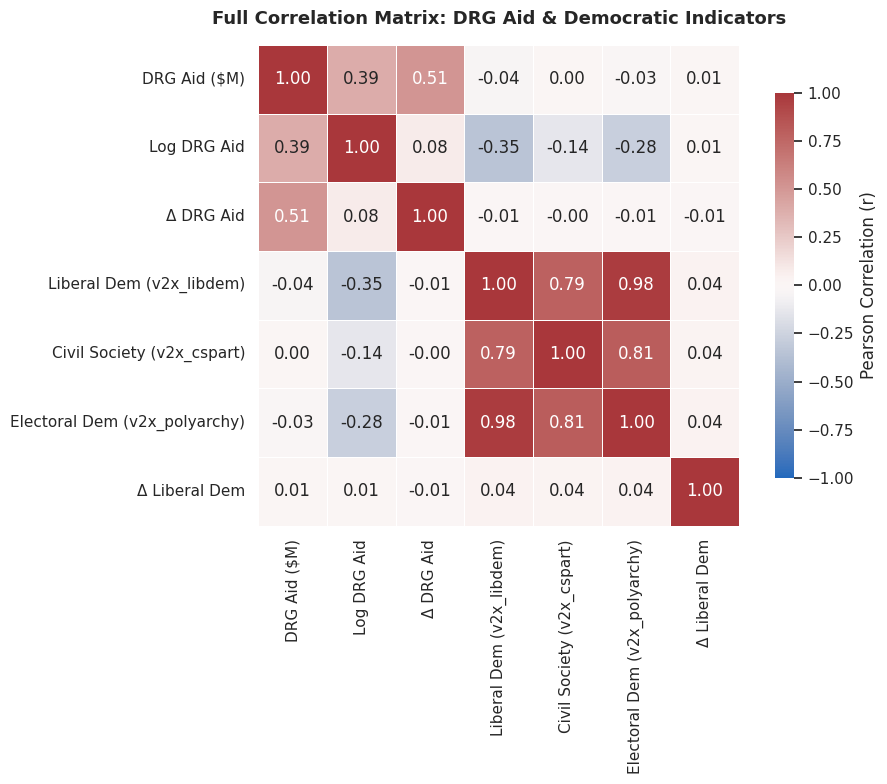

✅ Full correlation matrix heatmap saved to: ../outputs/fig_correlation_matrix_full.png


In [7]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

sns.set_theme(style="white")

# 1. Prepare numeric variables
# Calculate changes and log-transformed aid if not already present
df['aid_millions'] = df['aid_constant_amount'].fillna(0) / 1e6
df['log_aid'] = np.log10(df['aid_millions'] + 1)
df = df.sort_values(by=['country_text_id', 'year']).copy()

df['delta_libdem'] = df.groupby('country_text_id')['v2x_libdem'].diff()

# Select numeric columns for matrix
numeric_cols = [
    'aid_millions',
    'log_aid',
    'aid_delta',
    'v2x_libdem',
    'v2x_cspart',
    'v2x_polyarchy',
    'delta_libdem',
]

# Rename columns for cleaner display labels
label_mapping = {
    'aid_millions': 'DRG Aid ($M)',
    'log_aid': 'Log DRG Aid',
    'aid_delta': 'Δ DRG Aid',
    'v2x_libdem': 'Liberal Dem (v2x_libdem)',
    'v2x_cspart': 'Civil Society (v2x_cspart)',
    'v2x_polyarchy': 'Electoral Dem (v2x_polyarchy)',
    'delta_libdem': 'Δ Liberal Dem',
}

corr_df = df[numeric_cols].rename(columns=label_mapping)

# 2. Compute Pearson Correlation Matrix
corr_matrix = corr_df.corr(method='pearson')

# Save numerical correlation matrix to CSV
corr_csv_path = '../outputs/table_correlation_matrix.csv'
corr_matrix.round(3).to_csv(corr_csv_path)
print(f'✅ Correlation matrix saved to CSV: {corr_csv_path}')

# 3. Plot Full Symmetric Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap='vlag',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation (r)'},
    ax=ax,
)

ax.set_title(
    'Full Correlation Matrix: DRG Aid & Democratic Indicators',
    fontsize=13,
    fontweight='bold',
    pad=15,
)

plt.tight_layout()

# Save image FIRST, then display
output_fig_path = '../outputs/fig_correlation_matrix_full.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Full correlation matrix heatmap saved to: {output_fig_path}')

In [13]:
# ========================================== #
# 2. GENERATE GLOBAL SUMMARY TABLE
# ========================================== #
# Aggregate global DRG aid totals and mean democracy indices by year
global_summary = df.groupby('year').agg(
    total_drg_aid=('aid_constant_amount', 'sum'),
    mean_polyarchy=('v2x_polyarchy', 'mean'),
    mean_libdem=('v2x_libdem', 'mean'),
    mean_cspart=('v2x_cspart', 'mean'),
    country_count=('country_text_id', 'nunique')
).reset_index()

# Format aid into millions of constant USD for readability
global_summary['total_drg_aid_millions'] = global_summary['total_drg_aid'] / 1e6

# Round the table values to 2 decimal points
global_summary_rounded = global_summary.round(2)

print("--- GLOBAL MACRO TREND SUMMARY (2001–2024) ---")
display(global_summary_rounded.head(10))

# Save table in the outputs folder
output_table_path = "../outputs/table_global_macro_trends.csv"
global_summary_rounded.to_csv(output_table_path, index=False)
print(f"\n✅ Rounded global summary table successfully saved to: {output_table_path}")

--- GLOBAL MACRO TREND SUMMARY (2001–2024) ---


,year,total_drg_aid,mean_polyarchy,mean_libdem,mean_cspart,country_count,total_drg_aid_millions
0,2001,3.211344e+09,0.49,0.39,0.64,197,3211.34
1,2002,2.125996e+09,0.50,0.39,0.64,200,2126.00
2,2003,8.529786e+09,0.51,0.40,0.65,198,8529.79
3,2004,6.644397e+09,0.51,0.40,0.65,205,6644.40
4,2005,7.059106e+09,0.52,0.40,0.66,204,7059.11
5,2006,3.414970e+09,0.52,0.41,0.66,203,3414.97
6,2007,4.030644e+09,0.52,0.40,0.66,207,4030.64
7,2008,4.582907e+09,0.52,0.41,0.66,207,4582.91
8,2009,5.676929e+09,0.52,0.41,0.66,206,5676.93
9,2010,6.465649e+09,0.52,0.41,0.67,204,6465.65



✅ Rounded global summary table successfully saved to: ../outputs/table_global_macro_trends.csv


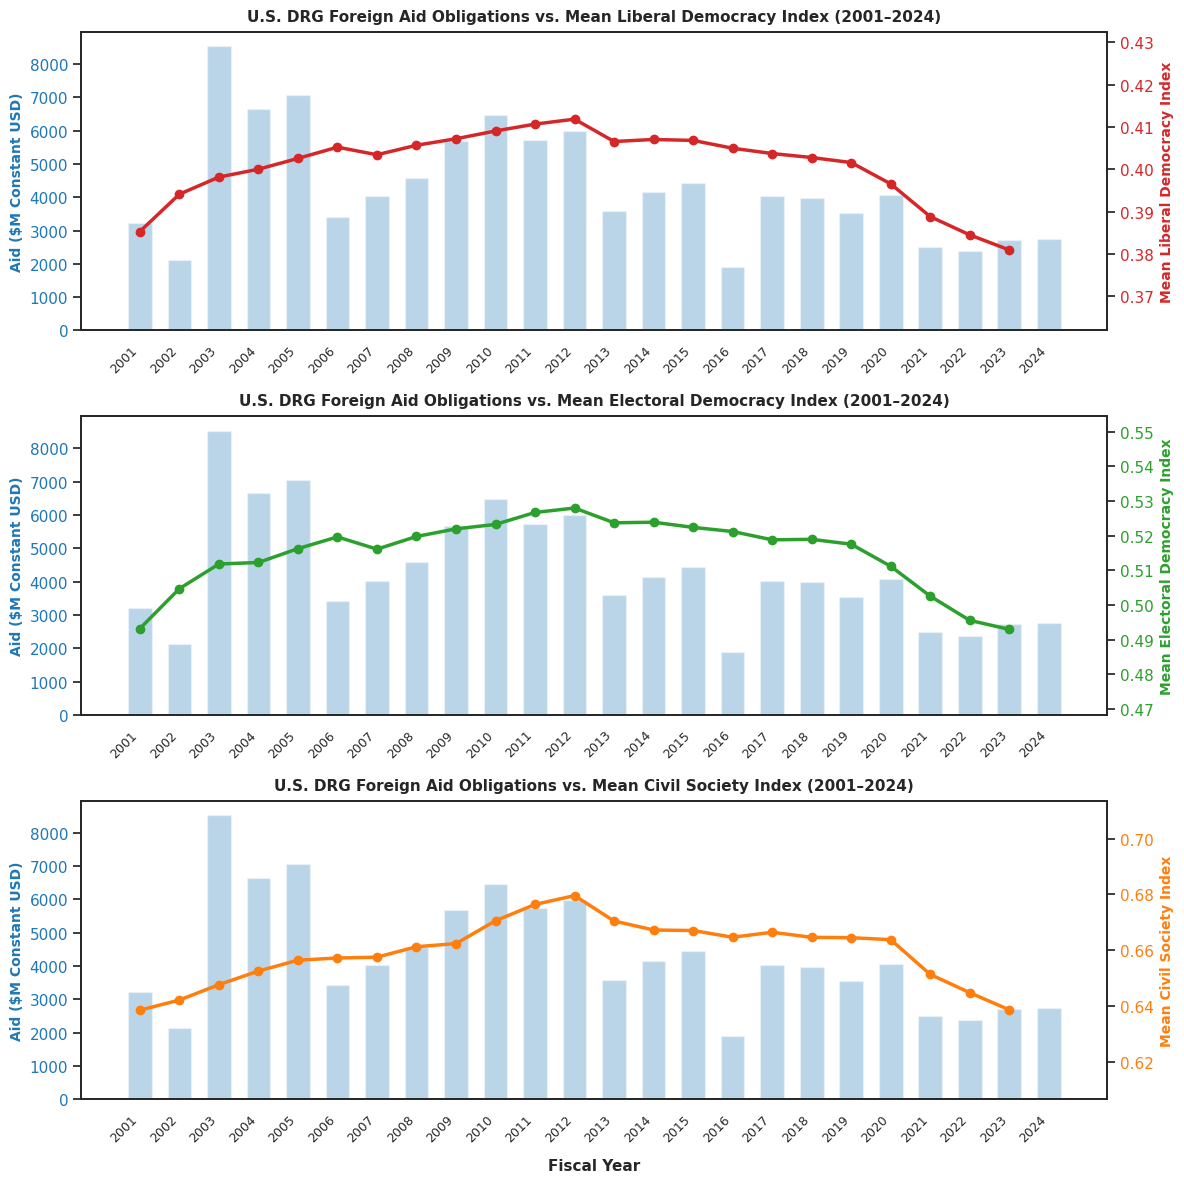

✅ 3-Panel Macro Trend Figure saved to: ../outputs/fig1_macro_trends_3panel.png


In [ ]:
# ==========================================
# 3. PLOT DUAL-AXIS GLOBAL MACRO TRENDS
# ==========================================
# Match exact column names created in global_summary
indices = [
    ('mean_libdem', 'Mean Liberal Democracy Index', '#d62728'),      # Crimson Red
    ('mean_polyarchy', 'Mean Electoral Democracy Index', '#2ca02c'),  # Emerald Green
    ('mean_cspart', 'Mean Civil Society Index', '#ff7f0e')          # Amber Orange
]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12), sharex=True)
color_aid = '#1f77b4'

for ax1, (col, title, color_vdem) in zip(axes, indices):
    # Primary Axis: Total DRG Aid Obligations (Bars)
    ax1.bar(
        global_summary['year'],
        global_summary['total_drg_aid_millions'],
        color=color_aid,
        alpha=0.3,
        width=0.6,
        label='DRG Aid Obligations ($M)'
    )
    ax1.set_ylabel('Aid ($M Constant USD)', color=color_aid, fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_aid)

    # Secondary Axis: V-Dem Democracy Index (Line)
    ax2 = ax1.twinx()
    ax2.plot(
        global_summary['year'],
        global_summary[col],  # Direct column reference
        color=color_vdem,
        linewidth=2.5,
        marker='o',
        label=title
    )
    ax2.set_ylabel(title, color=color_vdem, fontsize=10, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_vdem)

    # Force X-axis tick labels to show on every subplot
    ax1.tick_params(axis='x', labelbottom=True)
    ax1.set_xticks(global_summary['year'])
    ax1.set_xticklabels(global_summary['year'], rotation=45, ha='right', fontsize=9)

    # Set dynamic y-limits so line charts are clearly visible
    y_min = global_summary[col].min() * 0.95
    y_max = global_summary[col].max() * 1.05
    ax2.set_ylim(y_min, y_max)
    ax2.grid(False)

    # Panel Title
    ax1.set_title(f'U.S. DRG Foreign Aid Obligations vs. {title} (2001–2024)', fontsize=11, fontweight='bold', pad=8)

axes[-1].set_xlabel('Fiscal Year', fontsize=11, fontweight='bold', labelpad=10)
axes[-1].set_xticks(global_summary['year'])
axes[-1].set_xticklabels(global_summary['year'], rotation=45, ha='right')

plt.tight_layout()

# Save High-Res 3-Panel Output
output_3panel_path = "../outputs/fig1_macro_trends_3panel.png"
plt.savefig(output_3panel_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 3-Panel Macro Trend Figure saved to: {output_3panel_path}")

/tmp/ipykernel_593/2802458659.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


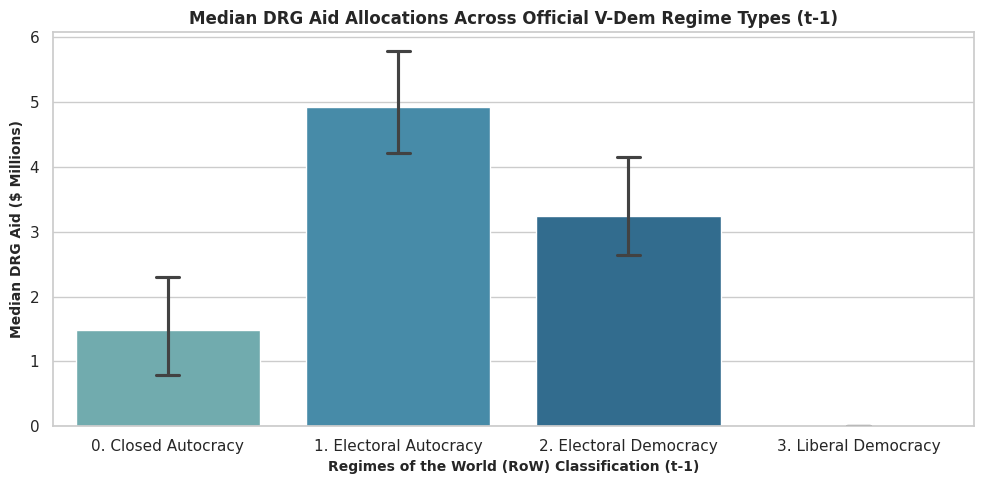

In [6]:
# ==========================================
# REGIME TYPES
# ==========================================

# Ensure 1-year lag of official regime classification
df = df.sort_values(by=['country_text_id', 'year']).copy()
df['v2x_regime_lag1'] = df.groupby('country_text_id')['v2x_regime'].shift(1)

# Map numerical codes to official V-Dem labels
vdem_regime_map = {
    0: '0. Closed Autocracy',
    1: '1. Electoral Autocracy',
    2: '2. Electoral Democracy',
    3: '3. Liberal Democracy',
}

df['regime_label_lag1'] = df['v2x_regime_lag1'].map(vdem_regime_map)

# Filter out missing values
plot_df = df.dropna(subset=['regime_label_lag1']).copy()

# Plot Median DRG Aid Allocation by Official V-Dem Regime Type
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=plot_df,
    x='regime_label_lag1',
    y='aid_millions',
    estimator=np.median,  # Median controls for high aid outliers
    palette='YlGnBu_d',
    capsize=0.1,
    ax=ax,
)

ax.set_title(
    'Median DRG Aid Allocations Across Official V-Dem Regime Types (t-1)',
    fontsize=12,
    fontweight='bold',
)
ax.set_xlabel(
    'Regimes of the World (RoW) Classification (t-1)',
    fontsize=10,
    fontweight='bold',
)
ax.set_ylabel('Median DRG Aid ($ Millions)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/fig_official_vdem_regime_aid.png', dpi=300)
plt.show()


# NOW THIS IS SOMEHTING OMG YES

In [ ]:
import pandas as pd

# 1. Create a copy and map integer codes to clean names
# Assuming 'df' is your current pandas DataFrame
df_dummies = df.copy()

regime_map = {
    0: 'Closed Autocracy',
    1: 'Electoral Autocracy',
    2: 'Electoral Democracy',
    3: 'Liberal Democracy',
}

df_dummies['regime_name'] = df_dummies['v2x_regime'].map(regime_map)

# 2. Generate One-Hot Encoded Dummy Variables
# We use 'prefix' to give clean names to the new columns
regime_dummies = pd.get_dummies(df_dummies['regime_name'], prefix='regime')

# The output of pd.get_dummies is Boolean by default, convert to integers (0, 1)
regime_dummies = regime_dummies.astype(int)

# 3. Concatenate the new dummies back to the original DataFrame
df_final = pd.concat([df_dummies, regime_dummies], axis=1)

# Display the first few rows of the main variables and the new dummies
display_cols = ['country_name', 'year', 'v2x_regime', 'regime_name'] + list(
    regime_dummies.columns
)
display(df_final[display_cols].head())

# ---------------------------------------------------------
# Step 4: Calculate Correlation Matrix with Aid
# ---------------------------------------------------------
df_final['log_aid'] = np.log10(df['aid_millions'] + 1)

# Select the variables for correlation analysis
corr_cols = ['aid_millions', 'log_aid'] + list(regime_dummies.columns)

# Calculate Pearson Correlation Matrix (round to 3 decimal places for readability)
correlation_matrix = df_final[corr_cols].corr(method='pearson').round(3)

# Display the final correlation table
print("\n--- Correlation Matrix: DRG Aid vs. Regime Type Dummies ---")
display(correlation_matrix)

,country_name,year,v2x_regime,regime_name,regime_Closed Autocracy,regime_Electoral Autocracy,regime_Electoral Democracy,regime_Liberal Democracy
0,Afghanistan,2001,0.0,Closed Autocracy,1,0,0,0
1,Afghanistan,2002,0.0,Closed Autocracy,1,0,0,0
2,Afghanistan,2003,0.0,Closed Autocracy,1,0,0,0
3,Afghanistan,2004,1.0,Electoral Autocracy,0,1,0,0
4,Afghanistan,2005,1.0,Electoral Autocracy,0,1,0,0



--- Correlation Matrix: DRG Aid vs. Regime Type Dummies ---


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,aid_millions,log_aid,regime_Closed Autocracy,regime_Electoral Autocracy,regime_Electoral Democracy,regime_Liberal Democracy
aid_millions,1.000,0.392,-0.014,0.046,-0.016,-0.042
log_aid,0.392,1.000,-0.025,0.183,0.102,-0.402
regime_Closed Autocracy,-0.014,-0.025,1.000,-0.246,-0.225,-0.188
regime_Electoral Autocracy,0.046,0.183,-0.246,1.000,-0.374,-0.313
regime_Electoral Democracy,-0.016,0.102,-0.225,-0.374,1.000,-0.286
regime_Liberal Democracy,-0.042,-0.402,-0.188,-0.313,-0.286,1.000


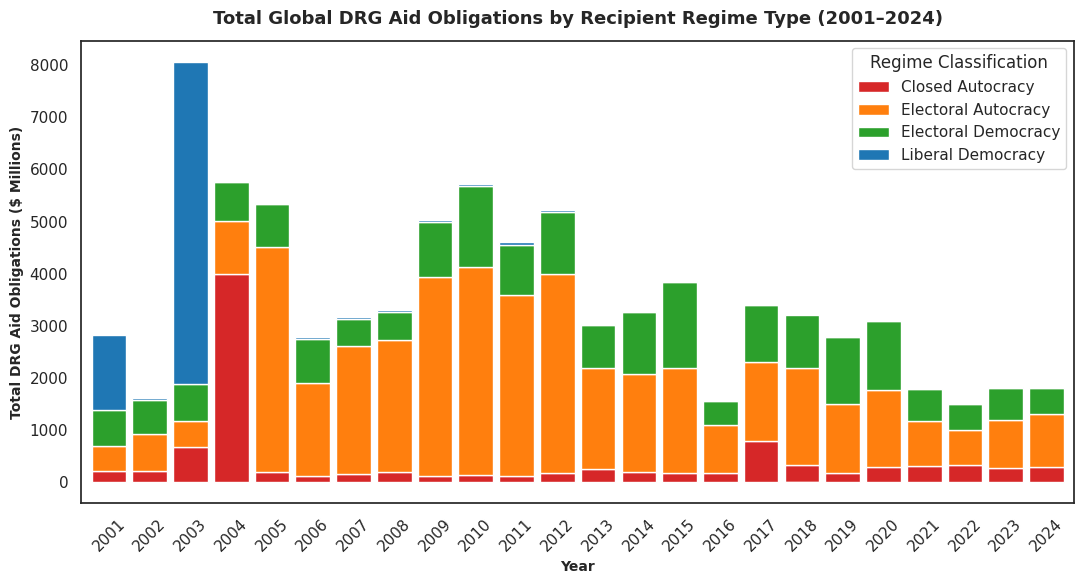

In [ ]:
sns.set_theme(style="white")

# Map integer codes to readable regime names
regime_map = {
    0: 'Closed Autocracy',
    1: 'Electoral Autocracy',
    2: 'Electoral Democracy',
    3: 'Liberal Democracy',
}

df['regime_name'] = df['v2x_regime'].map(regime_map)

# Aggregate total aid ($M) by year and regime type
yearly_regime_aid = (
    df.groupby(['year', 'regime_name'])['aid_millions']
    .sum()
    .unstack(fill_value=0)
)

# Reorder columns logically from most autocratic to most democratic
cols_order = [
    'Closed Autocracy',
    'Electoral Autocracy',
    'Electoral Democracy',
    'Liberal Democracy',
]
yearly_regime_aid = yearly_regime_aid.reindex(
    columns=[c for c in cols_order if c in yearly_regime_aid.columns]
)

# Plot Stacked Area / Bar Chart
fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']  # Red, Orange, Green, Blue
yearly_regime_aid.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors[: len(yearly_regime_aid.columns)],
    width=0.85,
)

ax.set_title(
    'Total Global DRG Aid Obligations by Recipient Regime Type (2001–2024)',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Year', fontsize=10, fontweight='bold')
ax.set_ylabel(
    'Total DRG Aid Obligations ($ Millions)', fontsize=10, fontweight='bold'
)
ax.legend(title='Regime Classification', frameon=True, facecolor='white')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/fig_stacked_aid_by_regime_year.png', dpi=300)
plt.show()

In [14]:
# 1. Filter dataset for 2003 and Liberal Democracies (v2x_regime == 3)
libdem_2001 = df[(df['year'] == 2004) & (df['v2x_regime'] == 0)].copy()

# 2. Sort by DRG aid descending and take the top 5
top5_libdem_2001 = libdem_2001.sort_values(
    by='aid_millions', ascending=False
).head(5)

# Select and format display columns
display_table = top5_libdem_2001[
    ['country_name', 'country_text_id', 'v2x_libdem', 'aid_millions']
].rename(
    columns={
        'country_name': 'Country',
        'country_text_id': 'Code',
        'v2x_libdem': 'Liberal Dem Index',
        'aid_millions': 'DRG Aid ($ Millions)',
    }
)

# Reset index for clean 1-5 ranking
display_table = display_table.reset_index(drop=True)
display_table.index = display_table.index + 1  # Rank 1 to 5

print("==========================================================")
print("  TOP 5 LIBERAL DEMOCRACIES RECEIVING DRG AID IN 2001     ")
print("==========================================================")
display(display_table.round(3))

  TOP 5 LIBERAL DEMOCRACIES RECEIVING DRG AID IN 2001     


,Country,Code,Liberal Dem Index,DRG Aid ($ Millions)
1,Iraq,IRQ,0.107,3886.091
2,China,CHN,0.073,28.453
3,Cuba,CUB,0.040,14.729
4,Angola,AGO,0.085,8.977
5,Burundi,BDI,0.151,8.889


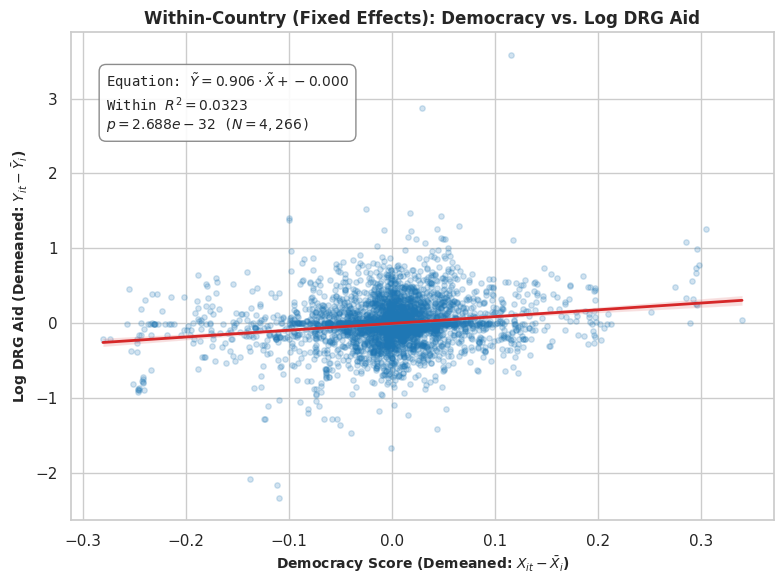

✅ Slope (Beta 1): 0.9059
✅ Within R-squared: 0.0323
✅ p-value: 2.6879e-32


In [ ]:
# ==========================================
# WITHIN COUNTRY DEMEANED (FIXED EFFECTS)
# ==========================================

# 1. Ensure Within-Country Demeaning (Fixed Effects Transform)
fe_df = df.copy()

# Calculate country-level means
fe_df['mean_libdem'] = fe_df.groupby('country_text_id')['v2x_libdem'].transform('mean')
fe_df['mean_aid'] = fe_df.groupby('country_text_id')['log_aid'].transform('mean')

# Demean variables
fe_df['libdem_demeaned'] = fe_df['v2x_libdem'] - fe_df['mean_libdem']
fe_df['log_aid_demeaned'] = fe_df['log_aid'] - fe_df['mean_aid']

# Drop NaN values for precise regression calculation
plot_data = fe_df.dropna(subset=['libdem_demeaned', 'log_aid_demeaned'])

# 2. Compute Linear Regression Stats (Slope, Intercept, R-squared, P-value)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    plot_data['libdem_demeaned'],
    plot_data['log_aid_demeaned']
)

within_r2 = r_value**2

# Format equation and stats strings
# Note: Intercept is ~0 due to demeaning
eq_text = f"Equation: $\\tilde{{Y}} = {slope:.3f} \\cdot \\tilde{{X}} + {intercept:.3f}$"
stats_text = f"Within $R^2 = {within_r2:.4f}$\n$p = {p_value:.3e}$ ($N = {len(plot_data):,}$)"

# 3. Create Plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=plot_data,
    x='libdem_demeaned',
    y='log_aid_demeaned',
    scatter_kws={'alpha': 0.2, 'color': '#1f77b4', 's': 15},
    line_kws={'color': '#d62728', 'linewidth': 2},
    ax=ax
)

# 4. Add Text Box Annotation with Equation and Within R^2
annotation_str = f"{eq_text}\n{stats_text}"

ax.text(
    0.05, 0.92, annotation_str,
    transform=ax.transAxes,
    fontsize=10,
    fontfamily='monospace',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

ax.set_title('Within-Country (Fixed Effects): Democracy vs. Log DRG Aid', fontsize=12, fontweight='bold')
ax.set_xlabel('Democracy Score (Demeaned: $X_{it} - \\bar{X}_i$)', fontsize=10, fontweight='bold')
ax.set_ylabel('Log DRG Aid (Demeaned: $Y_{it} - \\bar{Y}_i$)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/fig_fixed_effects_scatter_annotated.png', dpi=300)
plt.show()

print(f"✅ Slope (Beta 1): {slope:.4f}")
print(f"✅ Within R-squared: {within_r2:.4f}")
print(f"✅ p-value: {p_value:.4e}")

This means that when a country's democracy score improves by $+0.10$ relative to its historical national average, its Log DRG Aid increases by $+0.0906$ relative to its national average. Controlling for country-specific baseline effects, within-country shifts in democratic performance explain approximately 3% ($R^2_{\text{within}} = 0.0323$) of year-over-year variation in U.S. DRG aid allocations. There is a weak, statistically-significant positive correlation between demeaned democracy score and demeaned log DRG aid.